Series - is a single labeled 1-dimensional array
DataFrame - a 2 dimensional table (a collection of Series that share the same index)

In [78]:
!pip install pandas numpy
import pandas as pd 
import numpy as np

# series A
ages = pd.Series([32,34,56,65,32], name='age')  # ✅ Correct (capital S)
ages


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


0    32
1    34
2    56
3    65
4    32
Name: age, dtype: int64

In [79]:
ages.values

array([32, 34, 56, 65, 32])

In [80]:
ages.name

'age'

In [81]:
ages.info()


<class 'pandas.Series'>
RangeIndex: 5 entries, 0 to 4
Series name: age
Non-Null Count  Dtype
--------------  -----
5 non-null      int64
dtypes: int64(1)
memory usage: 172.0 bytes


1. Difference between iloc and loc
2. Correlation vs causation
3. Types of probability distributions 


I want to check how a change is logged using git r github

In [82]:
ages.head(6)

0    32
1    34
2    56
3    65
4    32
Name: age, dtype: int64

In [83]:
df = pd.DataFrame({
    'ages': [32, 34, 56, 65, 32],
    'names': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
})

In [84]:
df = pd.read_csv('iris.csv', index_col=0)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [86]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [87]:
df.shape

(150, 5)

In [88]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [89]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [90]:
df[df['sepal length (cm)'] > 7]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
102,7.1,3.0,5.9,2.1,2
105,7.6,3.0,6.6,2.1,2
107,7.3,2.9,6.3,1.8,2
109,7.2,3.6,6.1,2.5,2
117,7.7,3.8,6.7,2.2,2
118,7.7,2.6,6.9,2.3,2
122,7.7,2.8,6.7,2.0,2
125,7.2,3.2,6.0,1.8,2
129,7.2,3.0,5.8,1.6,2
130,7.4,2.8,6.1,1.9,2


In [91]:
df[['sepal length (cm)' , 'target']]

,sepal length (cm),target
0,5.1,0
1,4.9,0
2,4.7,0
3,4.6,0
4,5.0,0
...,...,...
145,6.7,2
146,6.3,2
147,6.5,2
148,6.2,2


In [92]:
df.loc [
    df['sepal length (cm)'] > 7,
    ['sepal length (cm)', 'target']
].to_csv('smaller_iris.csv')

### Measures of correlation
- Correlation
- Covariance - measures whether 2 variables move together (+ve move in the same direction while move in opposite direction)

- Pearson correlation coefficient 
Standardizes covariance to fall between -1 and +1
-1 perfect negative correlation 
0 - no linear correlation 
+1 - perfect positive correlation 




In [93]:
import numpy as np


rng = np.random.default_rng(42) #seed 

n = 25

study_hours = rng.uniform(1, 10, n).round(1)

#exam_score
exam_score = (40 + study_hours + 5 + rng.normal(0, 8, n)).round(1)
exam_score = np.clip(exam_score, 0, 100)

age = rng.integers(18, 45, n)


class_df = pd.DataFrame({
    'study_hours':study_hours,
    'exam_score':exam_score,
    'age':age}
)

class_df.head()

,study_hours,exam_score,age
0,8.0,50.2,39
1,4.9,54.2,39
2,8.7,56.6,39
3,7.3,55.6,35
4,1.8,50.2,30


In [94]:
#covariance between study hours and exam score
cov_matrix = class_df[['study_hours' , 'exam_score']].cov()
cov_matrix

,study_hours,exam_score
study_hours,6.364167,7.096500
exam_score,7.096500,38.504433


In [95]:
corr_study_score = class_df['study_hours'].corr(class_df['exam_score'])
corr_study_score

np.float64(0.4533337644677941)

In [96]:
corr_study_score = df.corr()

## Data Visualizaition with Python
- MatplotLib
- Seaborn

In [97]:
!pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


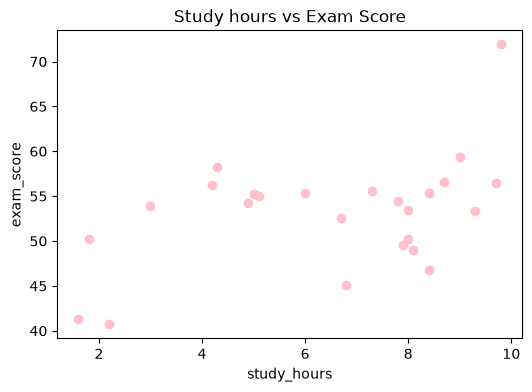

In [98]:
import matplotlib.pyplot as plt


#scatter plot
plt.figure(figsize=(6, 4))

plt.scatter(class_df['study_hours'], class_df['exam_score'], color = 'pink')
plt.title('Study hours vs Exam Score')
plt.xlabel('study_hours')
plt.ylabel('exam_score')
plt.show()

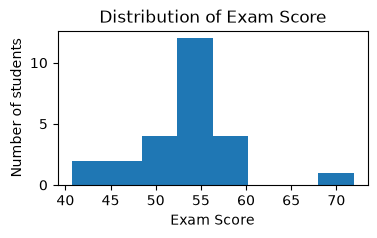

In [99]:
#histogram
plt.figure(figsize=(4, 2))

plt.hist(class_df['exam_score'], bins=8)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Number of students')
plt.show()


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


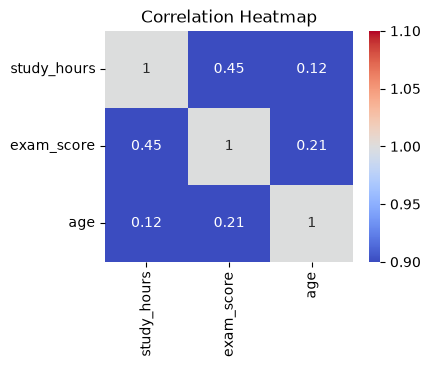

In [100]:
## correlation matrix
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(4, 3))

sns.heatmap(class_df.corr(), annot=True, cmap='coolwarm', vmin=1, vmax=1)

plt.title('Correlation Heatmap')
plt.show()

## Intro to Probability Distribution 
### Discrete Random Variables
- How likely the outcome of a particular variable occuring is
- Discrete random variables take on a countable set of values i.e. coin flip
- For discrete random variables, we use a 'Probability Mass Function' (PMF), which gives the exact probability for each specific value.

### Continuous Random Variables
- For continuous random variables, we take any value within a range, i.e. tempreture, height, time
- We use a 'Probability Density Function' (PDF)

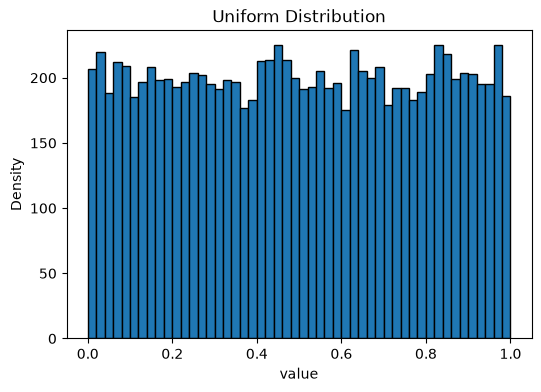

In [101]:
rng = np.random.default_rng (254)

uniform_samples = rng.uniform(0 , 1, 10000)

plt.figure(figsize=(6, 4))
plt.hist(uniform_samples, bins=50, edgecolor='black')
plt.title('Uniform Distribution')
plt.xlabel('value')
plt.ylabel('Density')
plt.show()

In [102]:
!pip install scipy 
import scipy


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


(array([2.33083065e-04, 2.24018723e-03, 1.03462983e-02, 2.61570995e-02,
        3.81997245e-02, 3.22431573e-02, 1.52539917e-02, 4.15664799e-03,
        5.82707662e-04, 7.76943550e-05]),
 array([133.95204082, 141.6746096 , 149.39717838, 157.11974716,
        164.84231594, 172.56488472, 180.2874535 , 188.01002228,
        195.73259106, 203.45515985, 211.17772863]),
 <BarContainer object of 10 artists>)

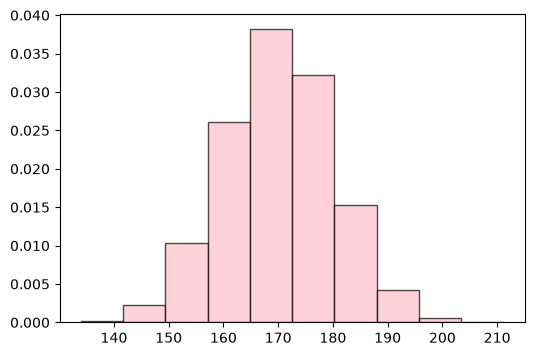

In [105]:
mean, std = 170, 10 
normal_samples = rng.normal(loc = mean, scale = std, size = 10000)

plt.figure(figsize = (6,4))
plt.hist(normal_samples, bins=10, edgecolor='black', color='pink', density=True, alpha=0.7)

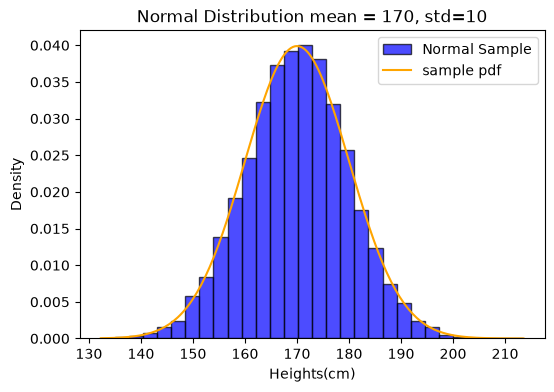

In [ ]:
#normal distribution of heights

mean, std = 170, 10
normal_samples = rng.normal(loc=mean, scale=std, size=10000)

plt.figure(figsize=(6, 4))
plt.hist(normal_samples, bins=30, edgecolor='black', color='blue', density=True, alpha=0.7, label='Normal Sample')

#pdf
x = np.linspace(normal_samples.min(), normal_samples.max(), 199)
plt.plot(x, scipy.stats.norm.pdf(x, loc=mean, scale=std), color='orange', label='sample pdf')

plt.title('Normal Distribution mean = 170, std=10')
plt.xlabel('Heights(cm)')
plt.ylabel('Density')
plt.legend()
plt.show()

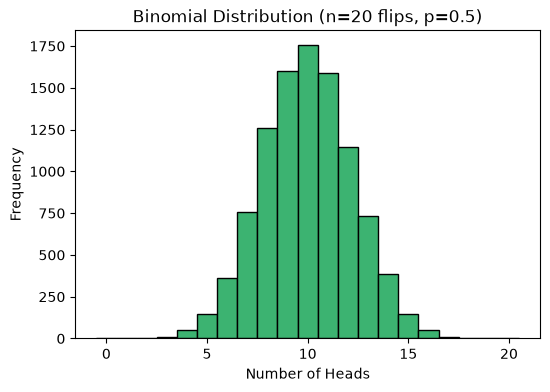

In [ ]:
binomial_samples = rng.binomial(n=20, p=0.5, size=10000)

plt.figure(figsize=(6, 4))
plt.hist(binomial_samples, bins=range(0, 22), edgecolor="black", color="mediumseagreen", align="left")
plt.title("Binomial Distribution (n=20 flips, p=0.5)")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")
plt.show()

### Intro to OOP 
A class:
An Attribute:
An object:

In [144]:
class Student:
    def __init__(self, first_name, last_name, subject):
        self.first_name = first_name
        self.last_name = last_name
        self.subject = subject
    def capitalize (self):
        full_name = self.first_name + " " + self.last_name
        return full_name.upper()
    def welcome(self):
        sentence = f"Dear {self.first_name.title()}, Welcome to Moringa School and the {self.subject} course!"
        return sentence
    


In [145]:
student_1 = Student('paul', 'nyawita', 'economics')
student_2 = Student('elsie', 'damar', 'electrical engineering')
student_3 = Student('reese', 'witherspoon', 'education')
student_4 = Student('george', 'anyango', 'physics')
student_5 = Student('dada', 'pam', 'p.e')
student_6 = Student('will', 'smith', 'education')

new_students = [
    student_1,
    student_2,
    student_3,
    student_4,
    student_5,
    student_6
]


In [149]:
for student in new_students:
    print(student.welcome())

Dear Paul, Welcome to Moringa School and the economics course!
Dear Elsie, Welcome to Moringa School and the electrical engineering course!
Dear Reese, Welcome to Moringa School and the education course!
Dear George, Welcome to Moringa School and the physics course!
Dear Dada, Welcome to Moringa School and the p.e course!
Dear Will, Welcome to Moringa School and the education course!


### Intro to Databases and SQL 
 - DDL - Data Definition Language - Create, alter, drop schema
 - DML - Data Manipulation Language - Data Manipulation
 - DCL - Data Control Language

In [150]:
import sqlite3